In [1]:
import napari
import shutil
from imagegrains import data_loader
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from cellpose import io, models

>> Initializing ImageGrains with CellposeSAM:


Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.10.18 
torch version:  	2.7.1+cu118! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## Download pre-trained models and demo data  
If you have not donwloaded the pre-trained models and demo data yet from github, please run the following cell to download them.

In [2]:
download_path = data_loader.download_files()

>> Downloading demo data to C:/Users/3DUser/imagegrains ...
>> Using cached model weights from: C:/Users/3DUser/imagegrains/models/IG2_full_set_cp_SAM


To use the demo files, please run the following cell.

In [3]:
#ascertain Cellpose version
try:
    from imagegrains import __cp_version__
except:
    __cp_version__ = 2

#set path to default model based on Cellpose version
if __cp_version__ < 4:
    model_path = f'{download_path}/models/IG2_full_set.200525'
    model_id = 'IG2_full_set'
elif __cp_version__ >= 4:
    model_path = f'{download_path}/models/IG2_full_set_cp_SAM'
    model_id = 'IG2_full_set_cp_SAM'

Alternatively, you can use the model of [Schuster et al. (2025)](https://doi.org/10.1111/bor.70023), which is available from [this repository](https://github.com/BSchusterFR/Schuster_etal_2025_data_repository). Please note that this model requires the Cellpose legacy version (<`4.0`). You can install it with
 `pip install cellpose==2.3.2`.   
After downloading, please update `model_path` and `model_id`.

Initialize the model

In [4]:
model = models.CellposeModel(gpu=True,
                             pretrained_model=model_path);

### Segment in 3D

In [6]:
#load tiff stack
tif_stack=io.imread('E:/David/IG2/CT_Dove/sliced/CTD_003_200_600.tif')

#run inference with 3D flow of Cellpose-SAM
masks, flows, _ = model.eval(tif_stack, do_3D=True,z_axis=0)

#save segmented grains
io.imsave(f'E:/David/IG2/CT_Dove/sliced/CTD_003_200_600_flow_3D_{model_id}_pred.tif',masks)

100%|██████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 5352.59it/s]


### Inspect grains in 3D with napari

If you have the [napari](https://github.com/napari/napari)-based GUI installed, you can visualiize and modify the grains in 3D.   
To install it, you can use `pip install git+https://github.com/dmair1989/napari-imagegrains.git` (see [instructions](https://github.com/dmair1989/imagegrains?tab=readme-ov-file#how-does-it-work) for more details).

100%|██████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 4503.27it/s]


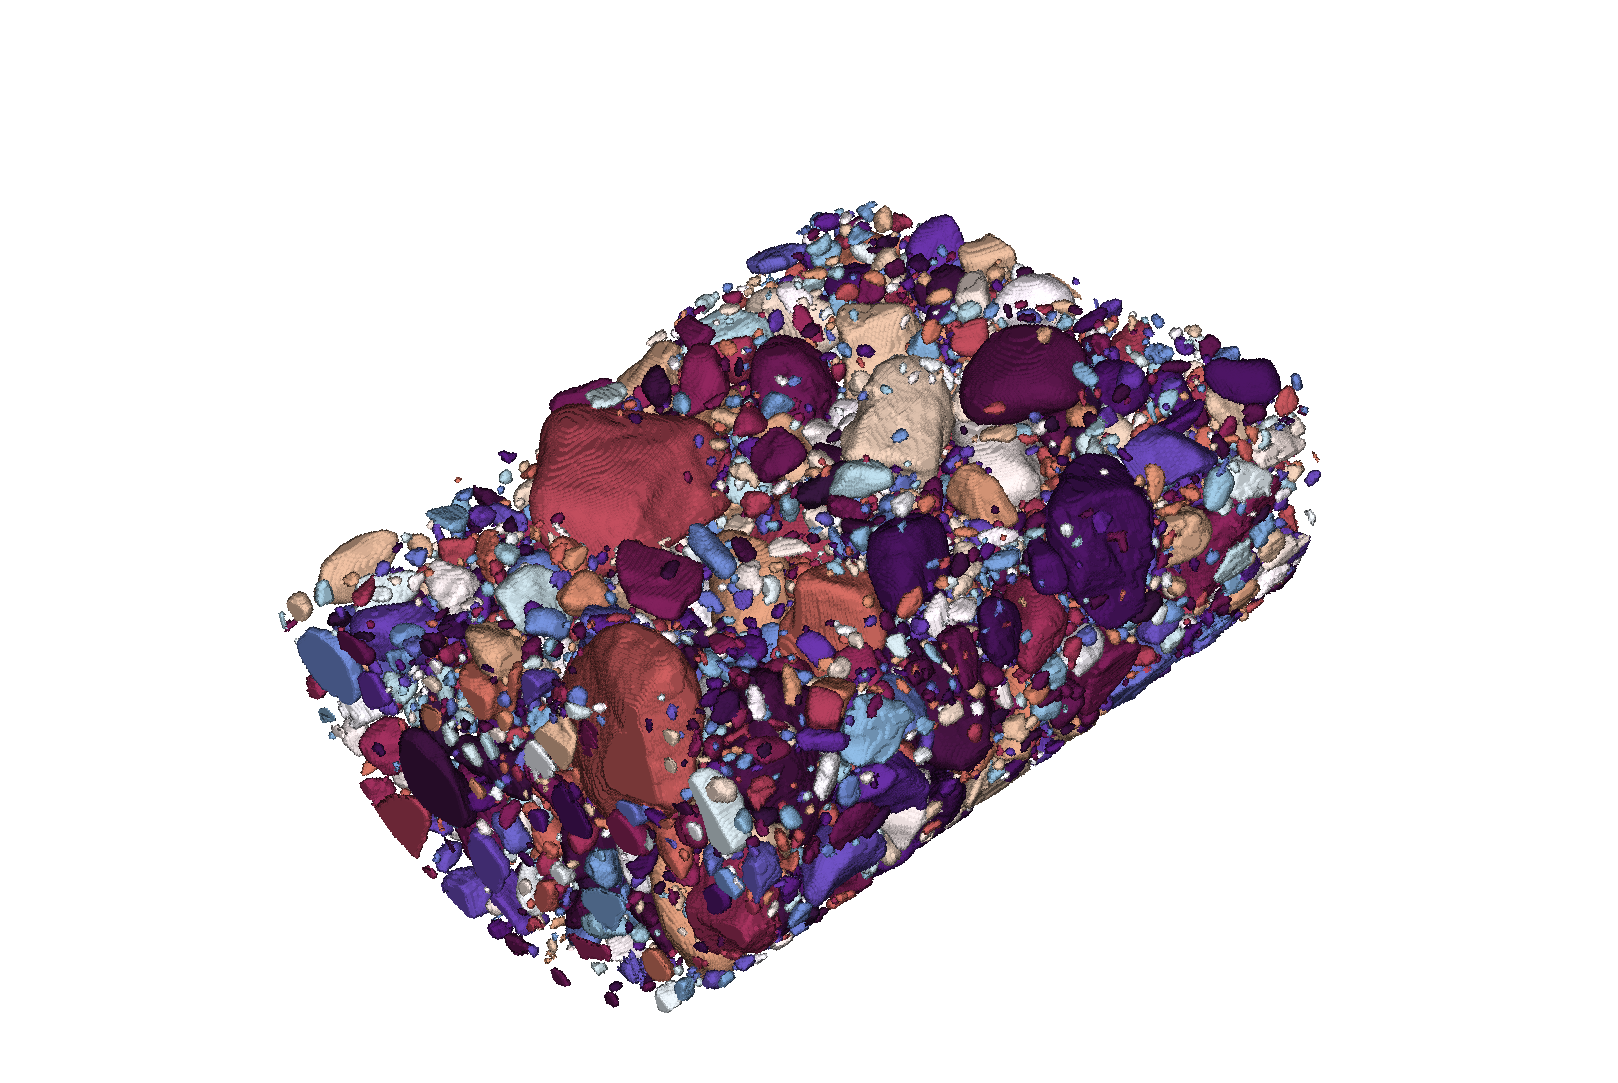

In [15]:
#set up napari viewer
viewer = napari.Viewer()
napari.settings.SETTINGS.application.window_maximized = True

#load segmented grains
mask_stack=io.imread(f'E:/David/IG2/CT_Dove/sliced/CTD_003_200_600_flow_3D_{model_id}_pred.tif')

#set colormap
cmap = plt.get_cmap('twilight_shifted', len(np.unique(mask_stack)))
cmp = [cmap(x) for x in range(len(np.unique(mask_stack)))]
np.random.shuffle(cmp)

#add CT image stack
image_layer = napari.imshow(tif_stack,viewer=viewer,visible=False)

#add grains as labels layer
labels_layer = viewer.add_labels(mask_stack, name=f'{model_id}_pred',iso_gradient_mode='smooth',opacity=1,colormap=cmp)

#switch to 3D view
viewer.dims.ndisplay = 3

#set camera view
viewer.camera.angles = [-20,45,45]
viewer.camera.zoom = 2
viewer.theme='light'
    
#create screen shot
napari.utils.NotebookScreenshot(viewer=viewer,canvas_only=True)